In [1]:
import ROOT
base_path = "/nfs/cms/arqolmo/SiWECALTB2026/Data/"
files ={"74":f"{base_path}ecal_TB2026CERN_run_000046.edm4hep.root",
        "52":f"{base_path}ecal_TB2026CERN_run_000045.edm4hep.root",
        "34":f"{base_path}ecal_TB2026CERN_run_000044.edm4hep.root",
        "20":f"{base_path}ecal_TB2026CERN_run_000043.edm4hep.root",
        "10":f"{base_path}ecal_TB2026CERN_run_000042.edm4hep.root",
        "7_5":f"{base_path}ecal_TB2026CERN_run_000041.edm4hep.root",
        
  }
# f = ROOT.TFile.Open(file)

In [2]:
from siwecal_common.edm4hep_pid import PidFileReader

r = PidFileReader(files["74"])
e = r.scalar("energy")
cols = r.scalar_columns(["zbary", "moliere", "is_shower"])
ids = r.identifiers()

print(e)
print(cols)

KeyInFileError: not found: 'events' (with any cycle number)

    Available keys: 'ecal;1'

in file /nfs/cms/arqolmo/SiWECALTB2026/Data/ecal_TB2026CERN_run_000046_dl.valcache.root

In [3]:
vars_eda = [
  "nhit",
  "zbary",
  "energy",
  "mip_likeness",
  "weighte",
  "bar_x",
  "bar_y",
  "bar_r",
  "moliere",
  "transverse_rms",
  "is_shower",
  "shower_start",
  "shower_max",
  "shower_end",
  "shower_start_10",
  "shower_end_10",
  "shower_length",
  "first_layer",
  "last_layer",
  "n_layers_hit",
  "e_over_nhit"	
]
vars_nn = vars_eda.copy()
nan_vars = ["is_shower",  "shower_start",
  "shower_max",
  "shower_end",
  "shower_start_10",
  "shower_end_10",
  "shower_length",]
for var_n in nan_vars:
  vars_nn.remove(var_n) # Contain nans
all_cols = r.scalar_columns(vars_eda)
print(vars_nn)


['nhit', 'zbary', 'energy', 'mip_likeness', 'weighte', 'bar_x', 'bar_y', 'bar_r', 'moliere', 'transverse_rms', 'first_layer', 'last_layer', 'n_layers_hit', 'e_over_nhit']


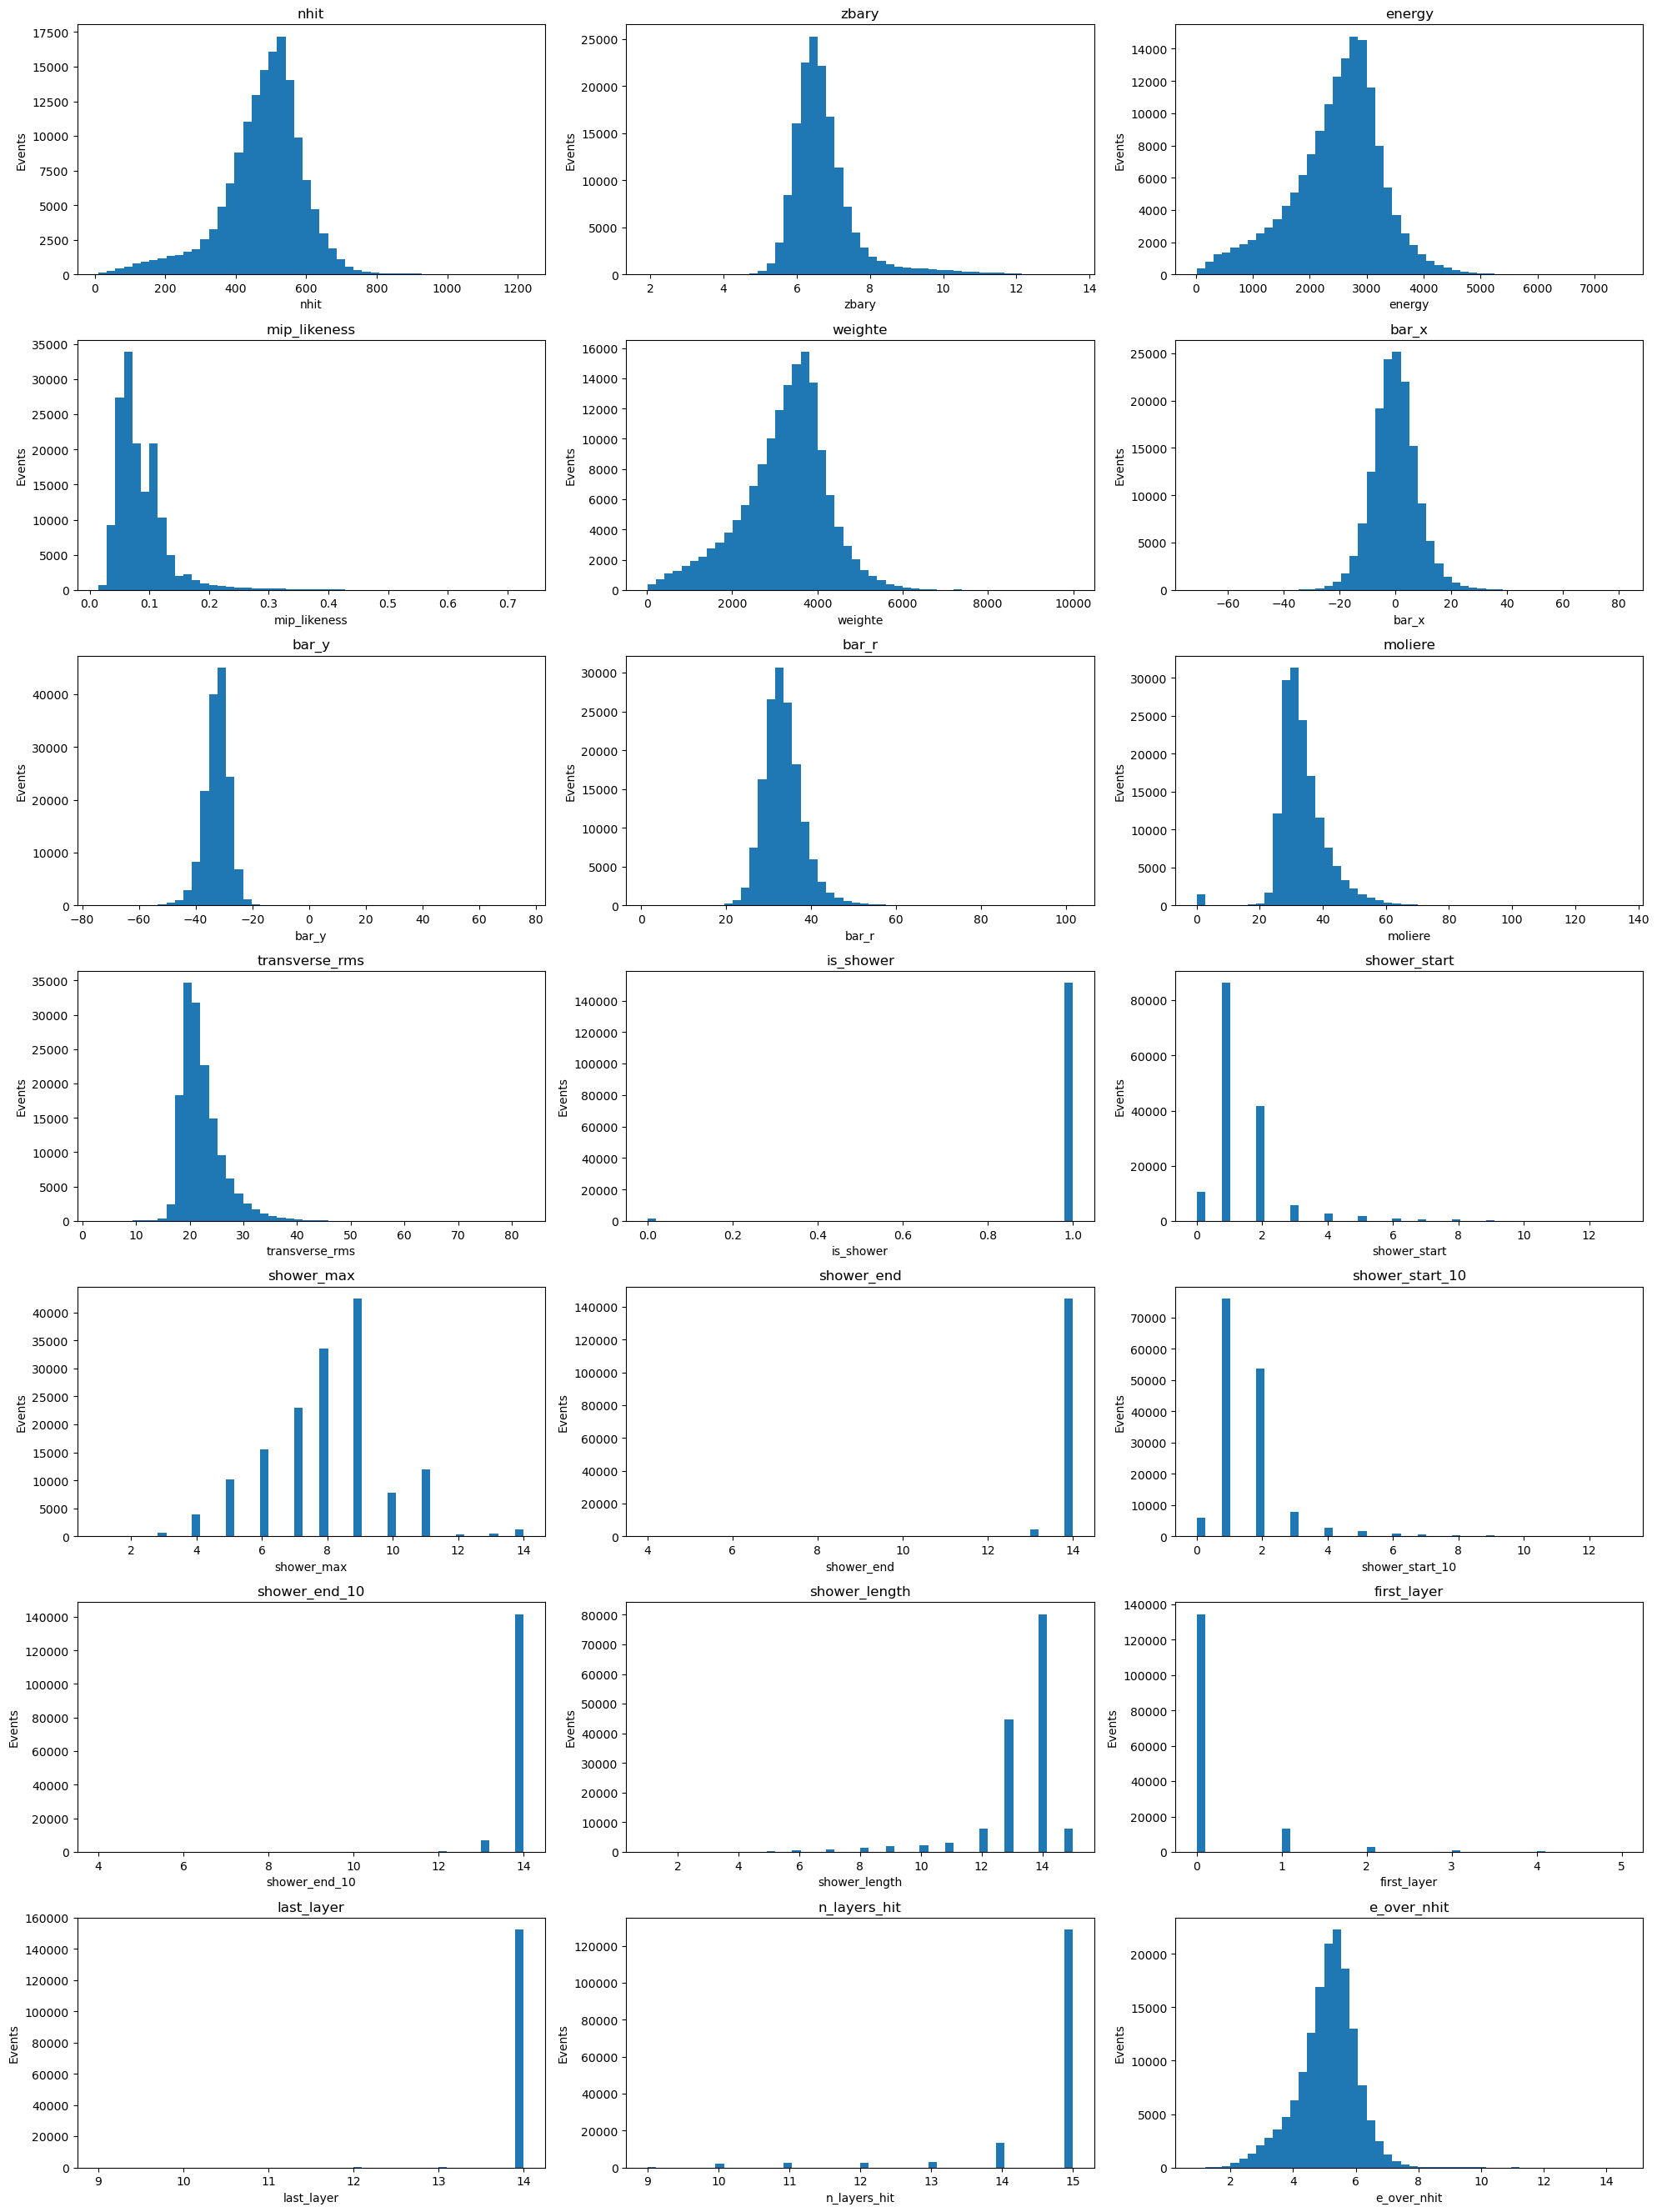

In [4]:
import matplotlib.pyplot as plt
n_vars = len(vars_eda)
fig = plt.figure(figsize=(20,30))
for i in range(n_vars):
  plt.subplot(n_vars//3 +1, 3, i+1)
  plt.hist(all_cols[vars_eda[i]], 50)
  plt.title(vars_eda[i])
  plt.xlabel(vars_eda[i])
  plt.ylabel("Events")
fig.set_tight_layout(True)
plt.show()

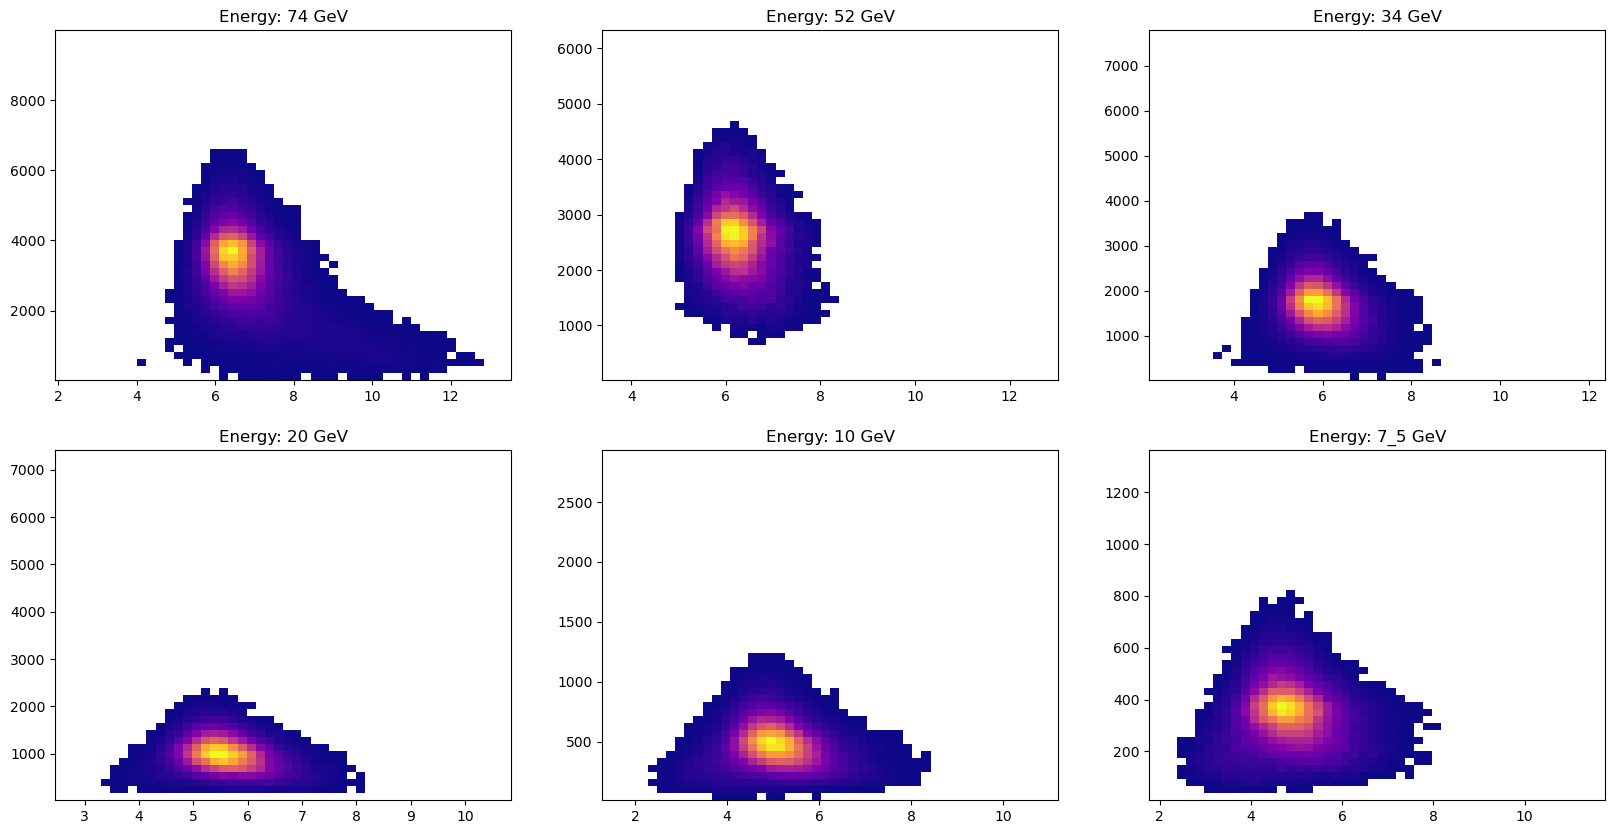

In [5]:
fig = plt.figure(figsize=(20,10))
for i, energy in enumerate(files.keys()):
  plt.subplot(len(files)//3, 3, i+1)
  r = PidFileReader(files[energy])
  cols = r.scalar_columns(["zbary", "weighte"])
  plt.hist2d(cols["zbary"], cols["weighte"], [50,50], cmap="plasma", cmin=10)
  plt.title(f"Energy: {energy} GeV")
plt.show()

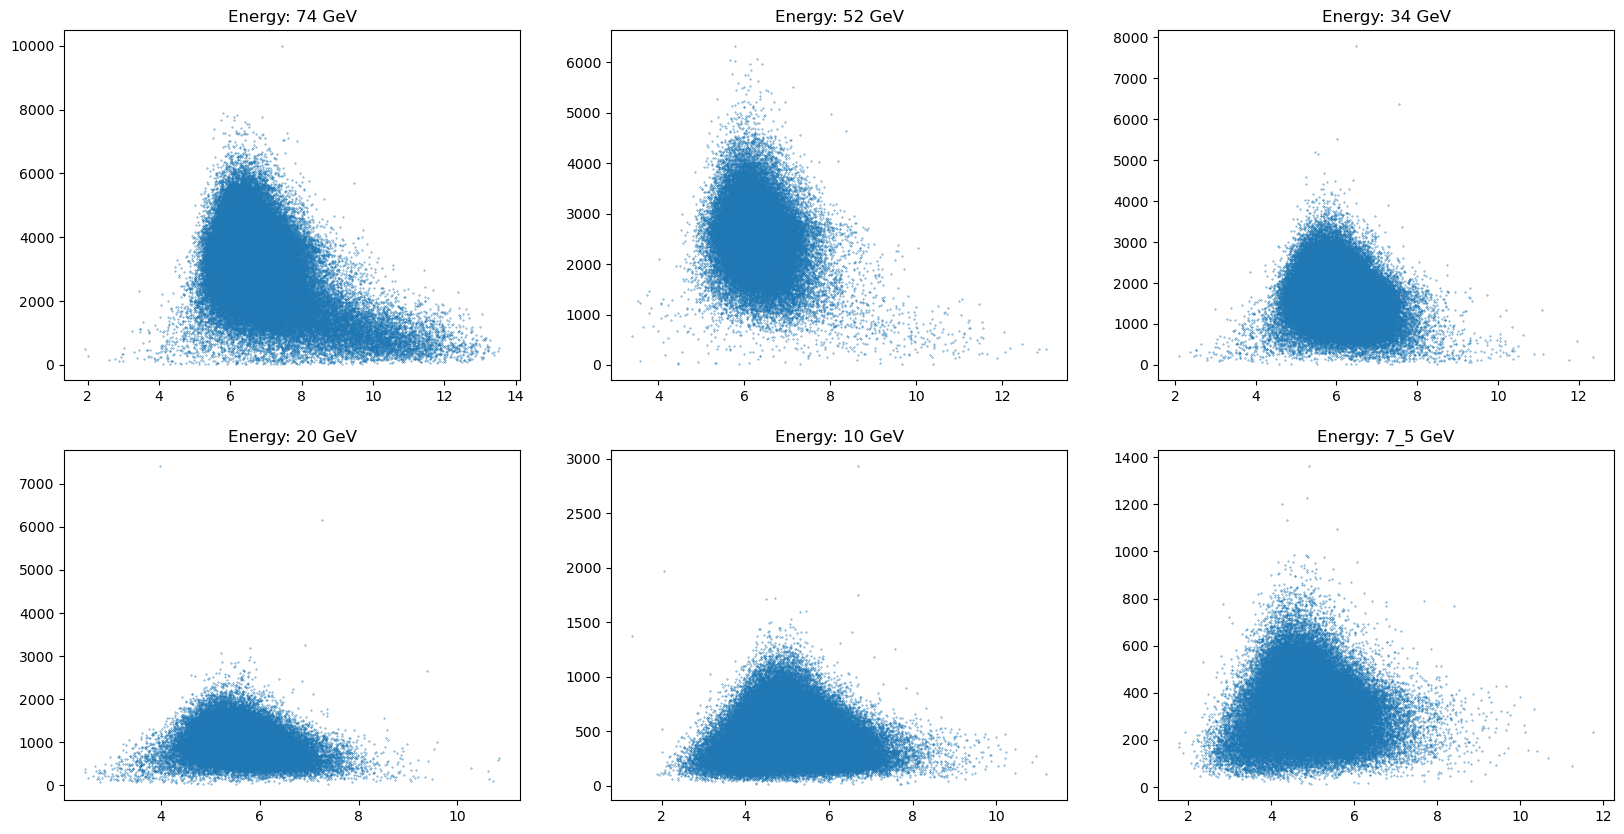

In [6]:
fig = plt.figure(figsize=(20,10))
for i, energy in enumerate(files.keys()):
  plt.subplot(len(files)//3, 3, i+1)
  r = PidFileReader(files[energy])
  cols = r.scalar_columns(["zbary", "weighte"])
  plt.scatter(cols["zbary"], cols["weighte"], s=0.1)
  plt.title(f"Energy: {energy} GeV")
plt.show()

In [7]:
# import pandas as pd
# import numpy as np
columns_to_analysis = ["e_over_nhit","moliere", "zbary", "transverse_rms", "mip_likeness", "nhit", "energy"]
# df = pd.DataFrame(np.transpose([all_cols[i] for i in vars_nn]),
#                   columns=vars_nn)
# pd.plotting.scatter_matrix(df[vars_nn], figsize=(10,10), s=2, alpha=.2)
# plt.show()

Analysis using 
['e_over_nhit', 'moliere', 'zbary', 'transverse_rms', 'mip_likeness', 'nhit', 'energy']


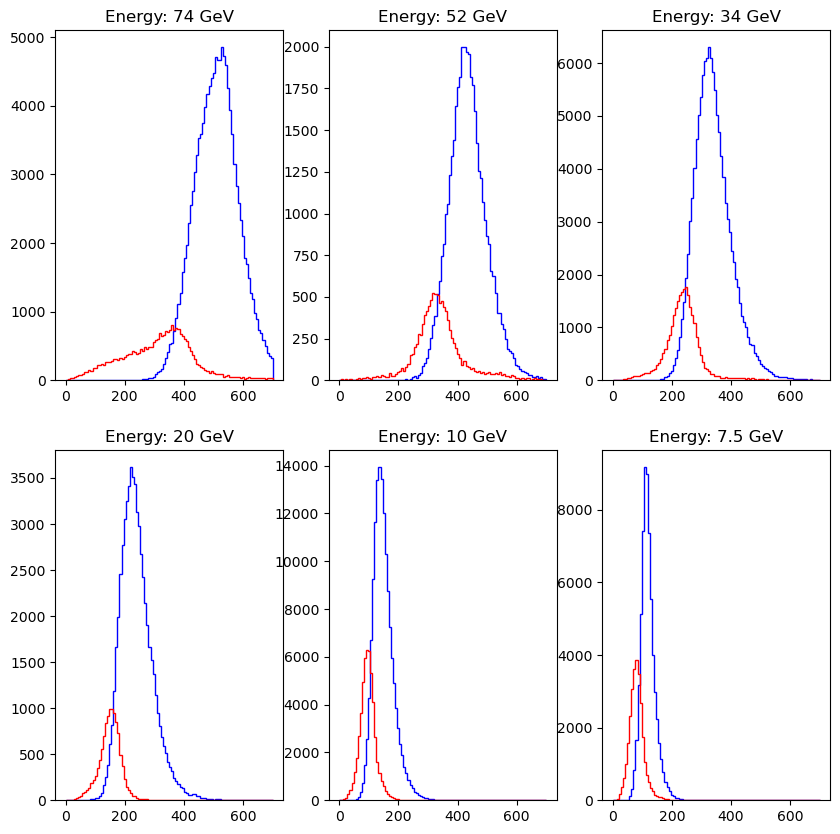

In [10]:
from sklearn.mixture import GaussianMixture
# from sklearn.mixture import BayesianGaussianMixture

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# fig = plt.figure(figsize=(20,10))
# energy="20"
fig = plt.figure(figsize=(10,10))
colors = ["blue", "red"]
# clust = BayesianGaussianMixture(n_components=2)
energy_labels = {}
std_sc = StandardScaler()
for i, energy in enumerate(files.keys()):
    clust = GaussianMixture(n_components=2, init_params="kmeans")

    plt.subplot(len(files)//3, 3, i+1)
    r = PidFileReader(files[energy])
    all_cols = r.scalar_columns(vars_eda)
    X = np.transpose([all_cols[i] for i in columns_to_analysis])
    # print(X.shape)
    X_scaled = std_sc.fit_transform(X=X)
    labels =clust.fit_predict(X)
    clust_0_count = np.where(labels==np.unique(labels)[0])[0].shape[0]
    clust_1_count = np.where(labels==np.unique(labels)[1])[0].shape[0]
    if clust_0_count > clust_1_count:
        major_clust = np.unique(labels)[0]
        minor_clust = np.unique(labels)[1]
    else:
        major_clust = np.unique(labels)[1]
        minor_clust = np.unique(labels)[0]
        
    for c, k in enumerate([major_clust, minor_clust]):
        X_k = X[labels == k]
        # -2 is nhits, -3 is mip likeness
        plt.hist(X_k[:,-2], range=[0,700], bins = 100, histtype="step", color=colors[c])
        # plt.hist(X_k[:,-3], range=[0,1], bins = 100, histtype="step", color=colors[c])
        # plt.scatter(X_k[:, 0], X_k[:, 1], s=0.1, label=f"cluster {k}")
    # print(energy)
    if energy == "7_5":
        energy = 7.5
    energy_labels[energy]={"major":labels == major_clust, "minor_clust":labels == minor_clust, "X":X}
    # plt.scatter(cols["zbary"], cols["weighte"], s=0.1)
    plt.title(f"Energy: {energy} GeV")
print("Analysis using ")
print("================="*5)
print(columns_to_analysis)
print("================="*5)

plt.show()

In [62]:
from scipy.optimize import curve_fit
from scipy.stats import crystalball
import numpy as np
import matplotlib.pyplot as plt


def cb_func(x, A, beta, m, mu, sigma):
    """Función Crystal Ball (scipy usa la variable estandarizada (x-mu)/sigma)."""
    return A * crystalball.pdf((x - mu) / sigma, beta, m)


def fit_crystal_ball(data, max_range=1000, bins=100,
                      beta0=1.5, m0=2.0, sigma_max=None, maxfev=10000,
                      x_min=0.0):
    """
    Ajusta una Crystal Ball a un array de datos 1D en el rango [x_min, max_range].

    sigma_max=None -> 0.5 * (max_range - x_min).
    Devuelve (popt, bin_centers, counts) o (None, bin_centers, counts) si falla.
    """
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]

    counts, bin_edges = np.histogram(data, range=[x_min, max_range], bins=bins)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    bin_width = bin_edges[1] - bin_edges[0]

    if counts.sum() == 0:
        return None, bin_centers, counts

    span = max_range - x_min
    if sigma_max is None:
        sigma_max = 0.5 * span

    lower = np.array([0.0, 0.1, 1.01, x_min, 1e-6])
    upper = np.array([np.inf, 10.0, 50.0, max_range, sigma_max])

    A0 = counts.max() * bin_width
    mu0 = bin_centers[np.argmax(counts)]
    sel = data[(data >= x_min) & (data <= max_range)]
    sigma0 = np.std(sel)
    if not np.isfinite(sigma0) or sigma0 <= 0:
        sigma0 = 0.1 * span

    # el p0 debe caer estrictamente dentro de bounds o curve_fit falla
    p0 = np.clip([A0, beta0, m0, mu0, sigma0], lower, np.nextafter(upper, 0.0))
    bounds = (lower, upper)

    try:
        popt, pcov = curve_fit(cb_func, bin_centers, counts, p0=p0,
                                bounds=bounds, maxfev=maxfev)
    except (RuntimeError, ValueError) as err:
        print(f"  fit_crystal_ball: {type(err).__name__}: {err} (p0={p0})")
        return None, bin_centers, counts

    return popt, bin_centers, counts


def plot_energy_fits(energy_labels, max_range=1000, bins=100,
                      cluster_key="major", column_idx=-2,
                      figsize=(10, 10), ncols=3):
    """
    Hace el fit Crystal Ball para cada energía en energy_labels, pinta
    histograma + ajuste en un subplot, y devuelve el diccionario `results`.
    """
    energies = list(energy_labels.keys())
    nrows = len(energies) // ncols + (1 if len(energies) % ncols else 0)

    fig = plt.figure(figsize=figsize)
    results = {}

    for i, energy in enumerate(energies):
        plt.subplot(nrows, ncols, i + 1)

        X = energy_labels[energy]["X"]
        mask = energy_labels[energy][cluster_key]
        data = X[mask][:, column_idx]

        popt, bin_centers, counts = fit_crystal_ball(data, max_range=max_range, bins=bins)

        if popt is None:
            print(f"Ajuste fallido para energía {energy}")
            continue

        A_fit, beta_fit, m_fit, mu_fit, sigma_fit = popt
        sigma_fit = abs(sigma_fit)

        plt.hist(data, range=[0, max_range], bins=bins, histtype="step",
                  color="blue", label="datos")
        x_fit = np.linspace(0, max_range, 500)
        plt.plot(x_fit, cb_func(x_fit, *popt), color="black", lw=1.5,
                  label="ajuste Crystal Ball")
        plt.title(f"Energy: {energy} GeV — fit")
        plt.legend(fontsize=8)

        results[energy] = {"mean": mu_fit, "std": sigma_fit,
                            "beta": beta_fit, "m": m_fit}

    plt.tight_layout()
    plt.show()

    return results


def plot_resolution(results, figsize=(8, 6), color="darkred", title=None):
    """
    Pinta sigma/E vs E a partir del diccionario `results` devuelto por
    plot_energy_fits.
    """
    E_vals = np.array([float(e) for e in results.keys()])
    res_vals = np.array([results[e]["std"] / results[e]["mean"] for e in results.keys()])

    order = np.argsort(E_vals)
    E_vals = E_vals[order]
    res_vals = res_vals[order]

    plt.figure(figsize=figsize)
    plt.plot(E_vals, res_vals, "o-", color=color)
    plt.xlabel("E [GeV]")
    plt.ylabel(r"$\sigma / E$")
    plt.title(title or "Resolución en energía vs Energía (Crystal Ball)")
    plt.grid(True)
    plt.show()

    return E_vals, res_vals

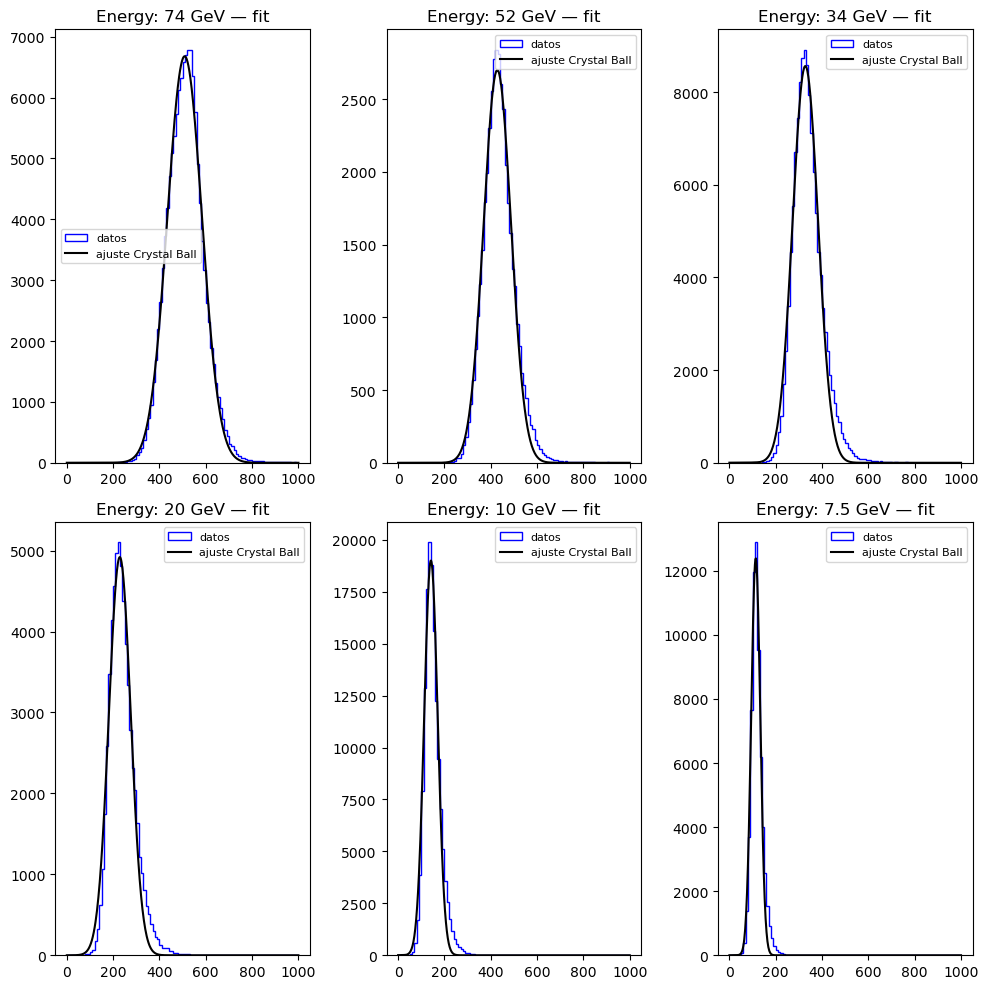

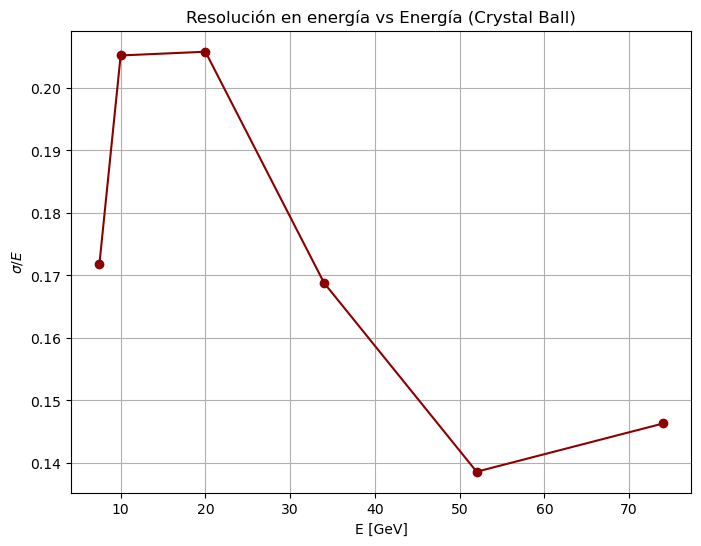

In [16]:
results = plot_energy_fits(energy_labels, max_range=1000, bins=100)
E_vals, res_vals = plot_resolution(results)

In [56]:
def gauss_func(x, A, mu, sigma):
    """Función gaussiana simple."""
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def fit_gaussian(data, max_range=1000, bins=100, sigma_max=None, maxfev=10000,
                  x_min=0.0):
    """
    Ajusta una gaussiana a un array de datos 1D en el rango [x_min, max_range].

    sigma_max=None -> 0.5 * (max_range - x_min).
    Devuelve (popt, bin_centers, counts) o (None, bin_centers, counts) si falla.
    popt = [A, mu, sigma]
    """
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]

    counts, bin_edges = np.histogram(data, range=[x_min, max_range], bins=bins)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    if counts.sum() == 0:
        return None, bin_centers, counts

    span = max_range - x_min
    if sigma_max is None:
        sigma_max = 0.5 * span

    lower = np.array([0.0, x_min, 1e-6])
    upper = np.array([np.inf, max_range, sigma_max])

    A0 = counts.max()
    mu0 = bin_centers[np.argmax(counts)]
    sel = data[(data >= x_min) & (data <= max_range)]
    sigma0 = np.std(sel)
    if not np.isfinite(sigma0) or sigma0 <= 0:
        sigma0 = 0.1 * span

    # el p0 debe caer estrictamente dentro de bounds o curve_fit falla
    p0 = np.clip([A0, mu0, sigma0], lower, np.nextafter(upper, 0.0))
    bounds = (lower, upper)

    try:
        popt, pcov = curve_fit(gauss_func, bin_centers, counts, p0=p0,
                                bounds=bounds, maxfev=maxfev)
    except (RuntimeError, ValueError) as err:
        print(f"  fit_gaussian: {type(err).__name__}: {err} (p0={p0})")
        return None, bin_centers, counts

    return popt, bin_centers, counts


def _resolve_range(energy, data, ranges, max_range, n_sigma_auto=4.0):
    """
    Decide el rango [lo, hi] de histograma/ajuste para una energía.

    ranges puede ser:
      None            -> [0, max_range] para todas (comportamiento antiguo)
      "auto"          -> rango por energía a partir de los propios datos
      dict            -> {energia: (lo, hi)}; las energías ausentes caen
                         al comportamiento por defecto
    """
    if isinstance(ranges, dict):
        r = ranges.get(energy)
        if r is not None:
            return float(r[0]), float(r[1])
        return 0.0, float(max_range)

    if isinstance(ranges, str) and ranges == "auto":
        if data.size == 0:
            return 0.0, float(max_range)
        med = np.median(data)
        # MAD -> sigma robusta, inmune a colas y outliers
        sigma = 1.4826 * np.median(np.abs(data - med))
        if not np.isfinite(sigma) or sigma <= 0:
            sigma = 0.5 * (np.max(data) - np.min(data)) or 1.0
        lo = max(0.0, med - n_sigma_auto * sigma)
        hi = med + n_sigma_auto * sigma
        if hi <= lo:
            hi = lo + 1.0
        return float(lo), float(hi)

    return 0.0, float(max_range)


def plot_energy_fits_from_arrays(y_true, y_reco, max_range=1000, bins=100,
                                  figsize=(10, 10), ncols=3,
                                  energy_decimals=None, fit_type="crystalball",
                                  ranges=None):
    """
    Para cada valor único de y_true, ajusta una Crystal Ball o una gaussiana
    (según fit_type) a los valores de y_reco correspondientes.

    Parámetros
    ----------
    y_true : array-like
        Energía verdadera (o etiqueta) de cada evento.
    y_reco : array-like
        Energía reconstruida de cada evento (misma longitud que y_true).
    energy_decimals : int or None
        Si y_true es continuo, número de decimales para redondear antes
        de agrupar. Si None, se usan los valores exactos.
    fit_type : str
        "crystalball" o "gauss". Elige el tipo de ajuste a realizar.
    ranges : None | "auto" | dict
        Rango de histograma y ajuste por energía. None usa [0, max_range]
        para todas; "auto" lo deduce de los datos (mediana ± 4 sigma robusta);
        un dict {energia: (lo, hi)} lo fija a mano por energía.

    Devuelve
    --------
    results : dict
        {energia: {"mean", "std", "beta", "m"}} para Crystal Ball
        {energia: {"mean", "std"}} para gaussiana
    """
    if fit_type not in ("crystalball", "gauss"):
        raise ValueError(f"fit_type debe ser 'crystalball' o 'gauss', recibido: {fit_type}")

    y_true = np.asarray(y_true)
    y_reco = np.asarray(y_reco)

    if energy_decimals is not None:
        y_true = np.round(y_true, energy_decimals)

    energies = np.unique(y_true)
    nrows = len(energies) // ncols + (1 if len(energies) % ncols else 0)

    fig = plt.figure(figsize=figsize)
    results = {}

    for i, energy in enumerate(energies):
        plt.subplot(nrows, ncols, i + 1)

        data = np.asarray(y_reco[y_true == energy], dtype=float)

        n_tot = data.size
        finite = np.isfinite(data)
        n_nan = int((~finite).sum())
        data_f = data[finite]

        lo, hi = _resolve_range(energy, data_f, ranges, max_range)
        n_in = int(((data_f >= lo) & (data_f <= hi)).sum())

        if fit_type == "crystalball":
            popt, bin_centers, counts = fit_crystal_ball(data_f, max_range=hi,
                                                          x_min=lo, bins=bins)
        else:
            popt, bin_centers, counts = fit_gaussian(data_f, max_range=hi,
                                                      x_min=lo, bins=bins)

        # el histograma se pinta siempre, ajuste o no
        plt.hist(data_f, range=[lo, hi], bins=bins, histtype="step",
                  color="blue", label="datos")
        plt.title(f"Energy: {energy} GeV — N={n_tot} (en rango: {n_in})")
        plt.annotate(f"N = {n_tot}\nen rango = {n_in}\nNaN = {n_nan}\n"
                      f"rango = [{lo:.3g}, {hi:.3g}]",
                      xy=(0.97, 0.97), xycoords="axes fraction",
                      ha="right", va="top", fontsize=8)

        if popt is None:
            print(f"Ajuste fallido para energía {energy}: "
                  f"N={n_tot}, finitos={n_tot - n_nan}, en [{lo:.3g},{hi:.3g}]={n_in}, "
                  f"min={np.min(data_f) if data_f.size else float('nan'):.3g}, "
                  f"max={np.max(data_f) if data_f.size else float('nan'):.3g}")
            plt.legend(fontsize=8)
            continue

        x_fit = np.linspace(lo, hi, 500)

        if fit_type == "crystalball":
            A_fit, beta_fit, m_fit, mu_fit, sigma_fit = popt
            sigma_fit = abs(sigma_fit)
            plt.plot(x_fit, cb_func(x_fit, *popt), color="black", lw=1.5,
                      label="ajuste Crystal Ball")
            results[energy] = {"mean": mu_fit, "std": sigma_fit,
                                "beta": beta_fit, "m": m_fit}
        else:
            A_fit, mu_fit, sigma_fit = popt
            sigma_fit = abs(sigma_fit)
            plt.plot(x_fit, gauss_func(x_fit, *popt), color="black", lw=1.5,
                      label="ajuste gaussiano")
            results[energy] = {"mean": mu_fit, "std": sigma_fit}

        plt.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    return results


In [18]:
X_data = []
y_data = []

for energy in energy_labels.keys():
  
  energy_float = energy
  energy_lab_file = energy if energy != 7.5 else "7_5"
  print(energy_float)
  # x = energy_labels[energy]["X"][energy_labels[energy]["major"]]
  r = PidFileReader(files[energy_lab_file])
  all_cols = r.scalar_columns(vars_nn)
  x = np.transpose([all_cols[i] for i in vars_nn])
  x = x[energy_labels[energy]["major"]]
  X_data.append(x)
  y_data.extend([energy_float]*x.shape[0])

X_data = np.vstack(X_data)
y_data = np.asarray(y_data)
# y_data = np.vstack(y_data)
print(X_data.shape, y_data.shape)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data,
    test_size=0.2,
    stratify=y_data,      # <-- clave: mantiene las proporciones de clases
    random_state=42
)
sc_X = StandardScaler()
sc_Y = StandardScaler()
sc_X.fit(X=X_train)
sc_Y.fit(X=y_train.reshape(-1,1))
X_train_scaled = sc_X.transform(X_train)
y_train_scaled = sc_Y.transform(y_train.reshape(-1,1))

X_test_scaled = sc_X.transform(X_test)
y_test_scaled = sc_Y.transform(y_test.reshape(-1,1))

y_test_scaled = y_test_scaled.squeeze(-1)
y_train_scaled = y_train_scaled.squeeze(-1)

print(X_train_scaled.shape, X_test_scaled.shape)
print(y_train_scaled.shape, y_test_scaled.shape)



74
52
34
20
10
7.5
(558112, 14) (558112,)
(446489, 14) (111623, 14)
(446489,) (111623,)


In [14]:
# np.sum(np.isnan(X_train_scaled))
[np.sum(np.isnan(X_data[:,i])) for i in range(X_data.shape[1])]


[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0)]

### Check for 52 differences

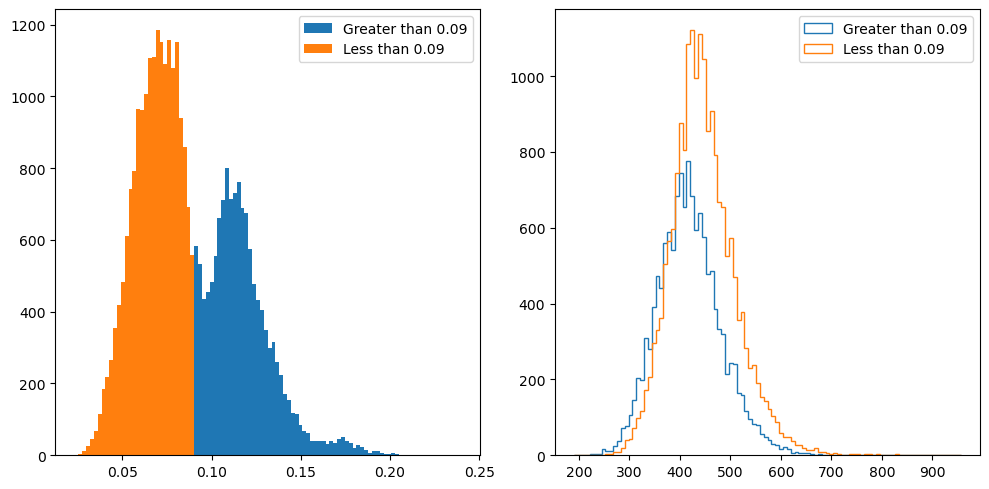

In [19]:
mip_cut = 0.09

mask_e = y_train == "52"

X_train_masked = X_train[mask_e, :]

mask_mip = X_train_masked[:,3]>mip_cut
fig = plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
min_r = min(np.min(X_train_masked[mask_mip,3]), np.min(X_train_masked[~mask_mip,3]))
max_r = max(np.max(X_train_masked[mask_mip,3]), np.max(X_train_masked[~mask_mip,3]))
plt.hist(X_train_masked[mask_mip,3], label=f"Greater than {mip_cut}", range=[min_r, max_r], bins=100)
plt.hist(X_train_masked[~mask_mip,3], label=f"Less than {mip_cut}", range=[min_r, max_r], bins=100)
plt.legend()
plt.subplot(1,2,2)

min_r = min(np.min(X_train_masked[mask_mip,0]), np.min(X_train_masked[~mask_mip,0]))
max_r = max(np.max(X_train_masked[mask_mip,0]), np.max(X_train_masked[~mask_mip,0]))
plt.hist(X_train_masked[mask_mip,0], label=f"Greater than {mip_cut}", range=[min_r, max_r], bins=100, histtype="step")
plt.hist(X_train_masked[~mask_mip,0], label=f"Less than {mip_cut}", range=[min_r, max_r], bins=100, histtype="step")
plt.legend()
fig.set_tight_layout(True)
plt.show()


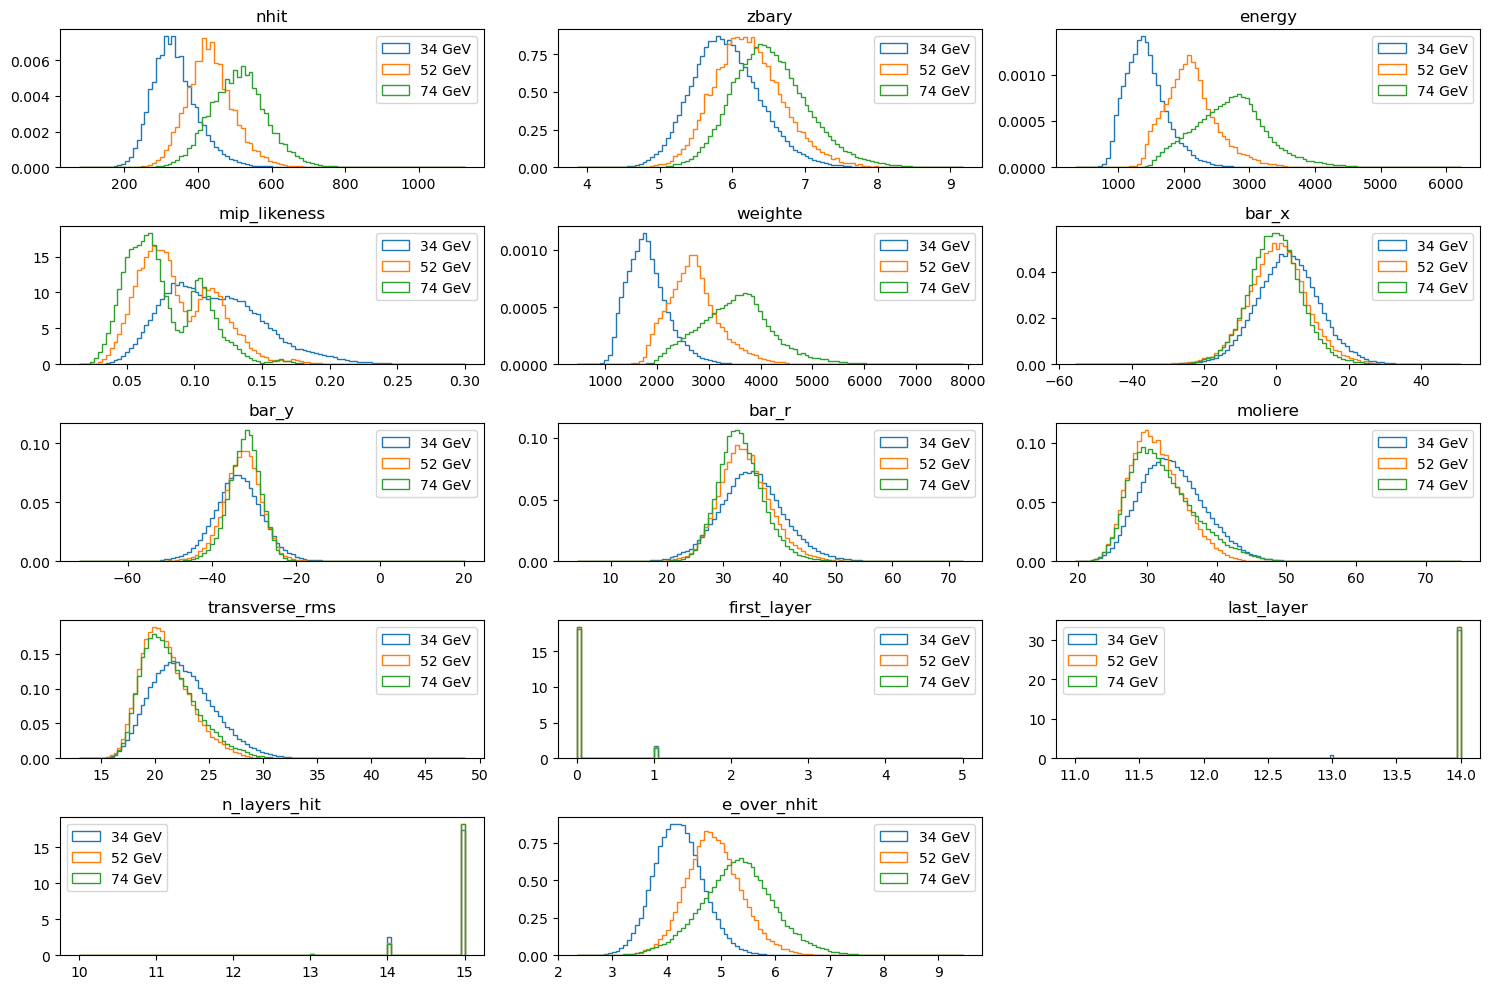

In [20]:
energy_to_show = ["34", "52", "74"]
fig = plt.figure(figsize=[15,10])
for i, variable in enumerate(range(X_train.shape[1])):
  n_rows = X_train.shape[1]//3 if X_train.shape[1]%3 == 0 else X_train.shape[1]//3 +1
  plt.subplot(n_rows, 3, i+1)
  mins = []
  maxs = []
  for e in energy_to_show:
    mask = y_train == e
    X_tmp = X_train[mask, variable]
    mins.append(min(X_tmp))
    maxs.append(max(X_tmp))
  # X_74 = X_train[mask, variable]
  min_r = min(*mins)
  max_r = max(*maxs)
  for e in energy_to_show:
  # print(X_52)
    mask = y_train == e
    X_tmp = X_train[mask, variable]
    plt.hist(X_tmp, bins=100, range=[min_r, max_r], label=f"{e} GeV", histtype="step", density=True)
  # plt.hist(X_74, bins=100, range=[min_r, max_r], label="74 GeV", histtype="step", density=True)
  
  plt.title(vars_nn[variable])
  plt.legend()
fig.set_tight_layout(True)
plt.show()

In [21]:
# Filter 52 with mip cut

mip_cut = 0.09

mask_52 = y_train == "52"
mask_cut = X_train[:, 3] > 0.09

composed_mask = mask_52 & mask_cut
# np.sum(composed_mask)
# np.sum(mask_52)

X_train_scaled_filtered = X_train_scaled[~composed_mask]
y_train_scaled_filtered = y_train_scaled[~composed_mask]
y_train_filtered = y_train[~composed_mask]

In [22]:
sample_weights = {}
w_e_total = 0
for e in np.unique(y_train):
  w_e =  (2*len(y_train)) / np.sum(y_train == e)
  
  sample_weights[e] = w_e
  w_e_total += w_e

for e in sample_weights:
  sample_weights[e] = 2*sample_weights[e]/w_e_total


sample_weight = [sample_weights[e] for e in y_train]


In [91]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(64,256,256,64),
                   activation="tanh", max_iter=200,
                   verbose=True, learning_rate="adaptive", tol = 0.0001)

mlp.fit(X_train_scaled, y_train_scaled, sample_weight=sample_weight)
y_pred = mlp.predict(X_test_scaled)

Iteration 1, loss = 0.03185982
Iteration 2, loss = 0.02922803
Iteration 3, loss = 0.02837900
Iteration 4, loss = 0.02794343
Iteration 5, loss = 0.02744848
Iteration 6, loss = 0.02707323
Iteration 7, loss = 0.02683935
Iteration 8, loss = 0.02661582
Iteration 9, loss = 0.02643729
Iteration 10, loss = 0.02632099
Iteration 11, loss = 0.02614292
Iteration 12, loss = 0.02614017
Iteration 13, loss = 0.02601127
Iteration 14, loss = 0.02592119
Iteration 15, loss = 0.02583015
Iteration 16, loss = 0.02580808
Iteration 17, loss = 0.02574173
Iteration 18, loss = 0.02566227
Iteration 19, loss = 0.02562097
Iteration 20, loss = 0.02559758
Iteration 21, loss = 0.02556710
Iteration 22, loss = 0.02557915
Iteration 23, loss = 0.02551514
Iteration 24, loss = 0.02547168
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


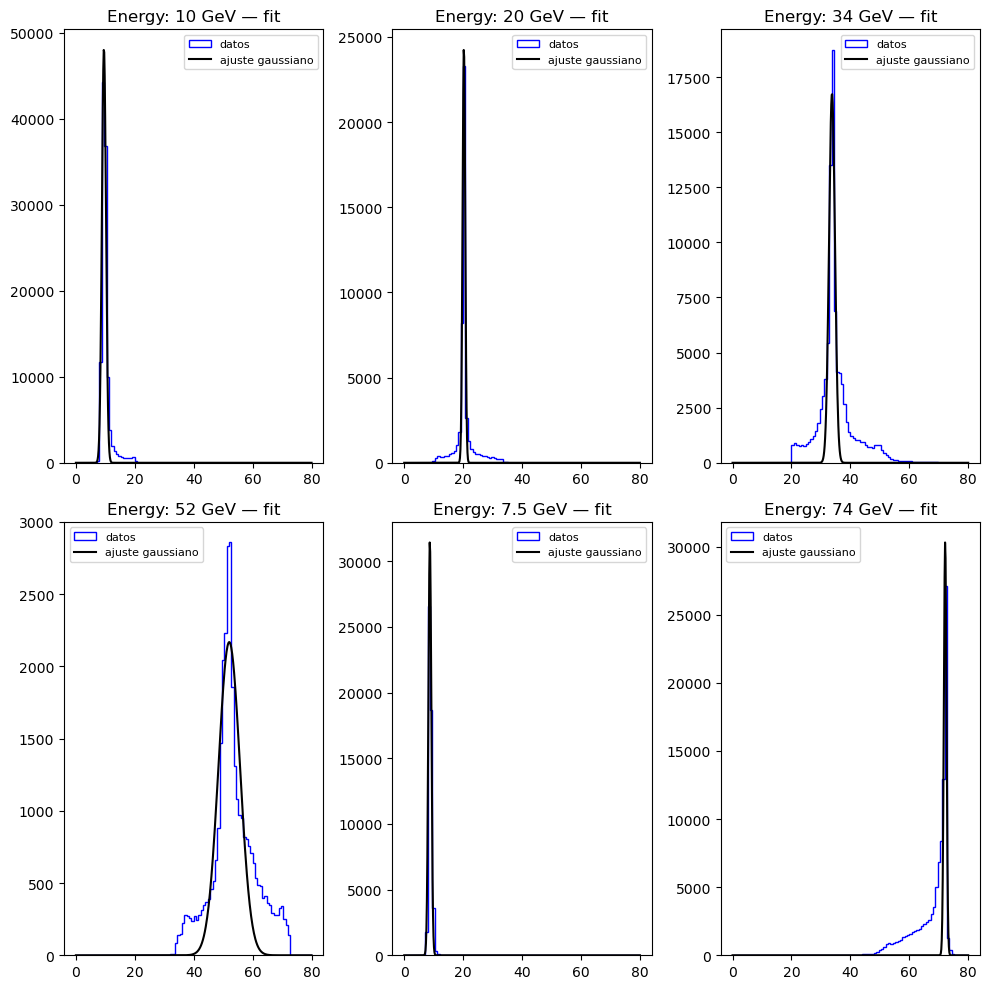

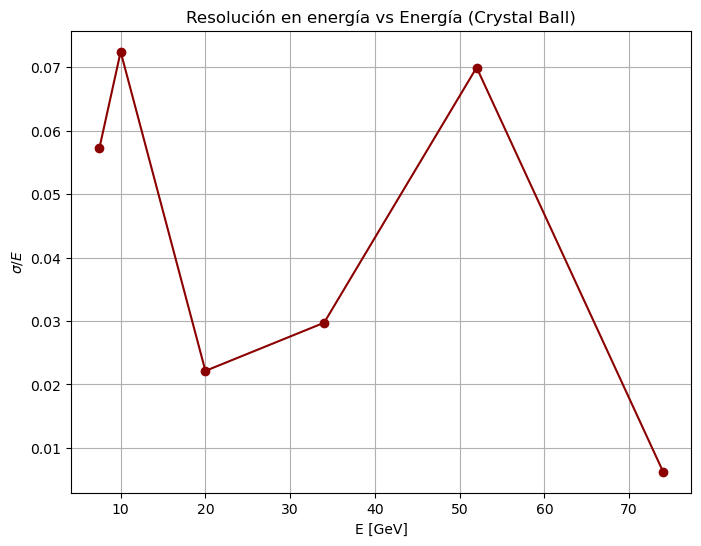

(array([ 7.5, 10. , 20. , 34. , 52. , 74. ]),
 array([0.05728925, 0.07244925, 0.02214448, 0.0297316 , 0.06996108,
        0.00625229]))

In [95]:
y_pred_train = mlp.predict(X_train_scaled)

y_pred_descaled = sc_Y.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_descaled = y_pred_descaled.squeeze(-1)
results=plot_energy_fits_from_arrays(y_train, y_pred_descaled, fit_type="gauss", max_range=80)
plot_resolution(results)

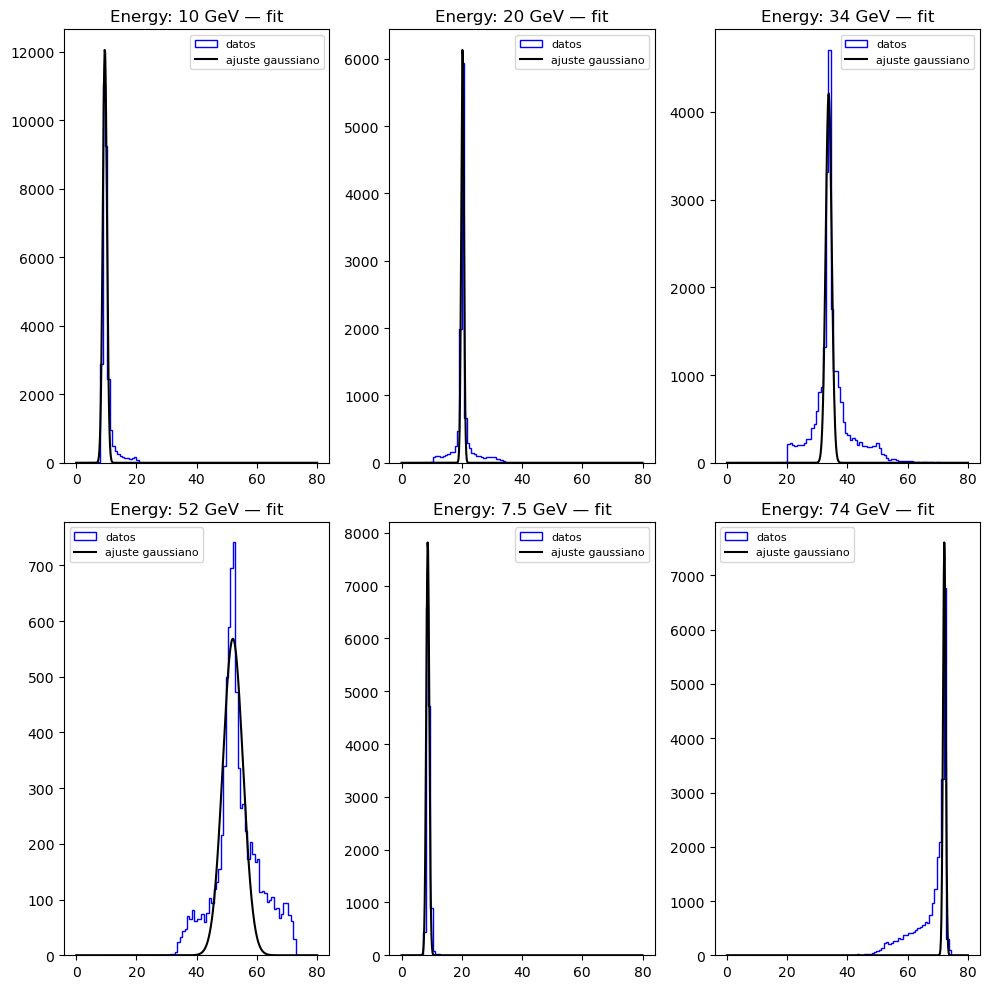

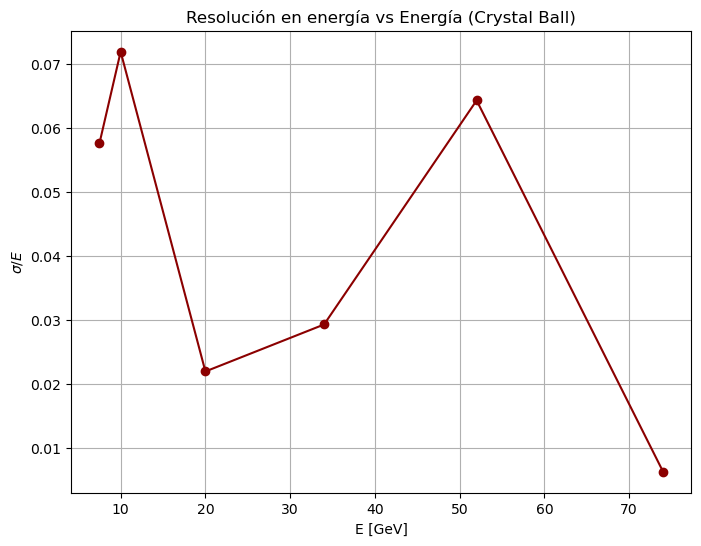

(array([ 7.5, 10. , 20. , 34. , 52. , 74. ]),
 array([0.05754983, 0.07186921, 0.02188653, 0.02922997, 0.06425841,
        0.0062151 ]))

In [96]:
y_pred_descaled = sc_Y.inverse_transform(y_pred.reshape(-1,1))
y_pred_descaled = y_pred_descaled.squeeze(-1)
results=plot_energy_fits_from_arrays(y_test, y_pred_descaled, fit_type="gauss", max_range=80)
plot_resolution(results)

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.svm import SVR
sv = SVR(kernel="poly")
# abr = AdaBoostRegressor(estimator=sv, loss="square")
sv.fit(X_train_scaled, y_train_scaled, sample_weight=sample_weight)

In [ ]:
y_pred = abr.predict(X_test_scaled)
y_pred_descaled = sc_Y.inverse_transform(y_pred.reshape(-1,1))
y_pred_descaled = y_pred_descaled.squeeze(-1)
results=plot_energy_fits_from_arrays(y_test, y_pred_descaled, fit_type="gauss", max_range=80)
plot_resolution(results)

In [ ]:
from sklearn.mixture import BayesianGaussianMixture
import numpy as np
# fig = plt.figure(figsize=(20,10))
fig = plt.figure(figsize=(20,10))

for i, energy in enumerate(files.keys()):
  clust = BayesianGaussianMixture(n_components=2)
  # plt.subplot(len(files)//3, 3, i+1)
  r = PidFileReader(files[energy])
  cols = r.scalar_columns(["zbary", "weighte"])
  X = np.vstack([cols["zbary"], cols["weighte"]])
  X = np.transpose(X)
  print(X.shape)
  labels =clust.fit_predict(X)
  for label in labels:
    X_k = X[labels==label]
    plt.scatter(X_k[0], X_k[1], s=0.1)    
  
  # plt.scatter(cols["zbary"], cols["weighte"], s=0.1)
  plt.title(f"Energy: {energy} GeV")
  plt.show()

# With Clustering Vars

In [64]:
import ROOT
import numpy as np
base_path = "/nfs/cms/arqolmo/SiWECALTB2026/Data/"
files ={"74":f"{base_path}ecal_TB2026CERN_run_000046_dl.valcache.root",
        "52":f"{base_path}ecal_TB2026CERN_run_000045_dl.valcache.root",
        "34":f"{base_path}ecal_TB2026CERN_run_000044_dl.valcache.root",
        "20":f"{base_path}ecal_TB2026CERN_run_000043_dl.valcache.root",
        "10":f"{base_path}ecal_TB2026CERN_run_000042_dl.valcache.root",
        "7_5":f"{base_path}ecal_TB2026CERN_run_000041_dl.valcache.root",
        
  }
# f = ROOT.TFile.Open(file)
dl_filter = {"dl_score":0.52,"dl_unmatched_fraction":0.22}
dfs_filtered = {}
for e in files:
  df = ROOT.RDataFrame("ecal", files[e])
  df_filtered = df
  for filter in dl_filter:
    filter_key = f"{filter}<{dl_filter[filter]}"
    # print(f"Filter {filter_key}")
    df_filtered = df_filtered.Filter(filter_key)
  print(f"=== Energy {e} GeV")
  w_pass = df_filtered.Count().GetValue()
  w_total = df.Count().GetValue()
  print(f"Pass {w_pass} of {w_total} ({round(w_pass/w_total,3)}%)")
  dfs_filtered[e] = df_filtered

In [66]:
energy_fit = []
real_e = []
for e in files:
  sum_energy = dfs_filtered[e].AsNumpy(["sum_energy"])["sum_energy"]
  energy_fit.extend(list(sum_energy))
  real_e.extend([e]*len(sum_energy))
# plot_energy_fits_from_arrays

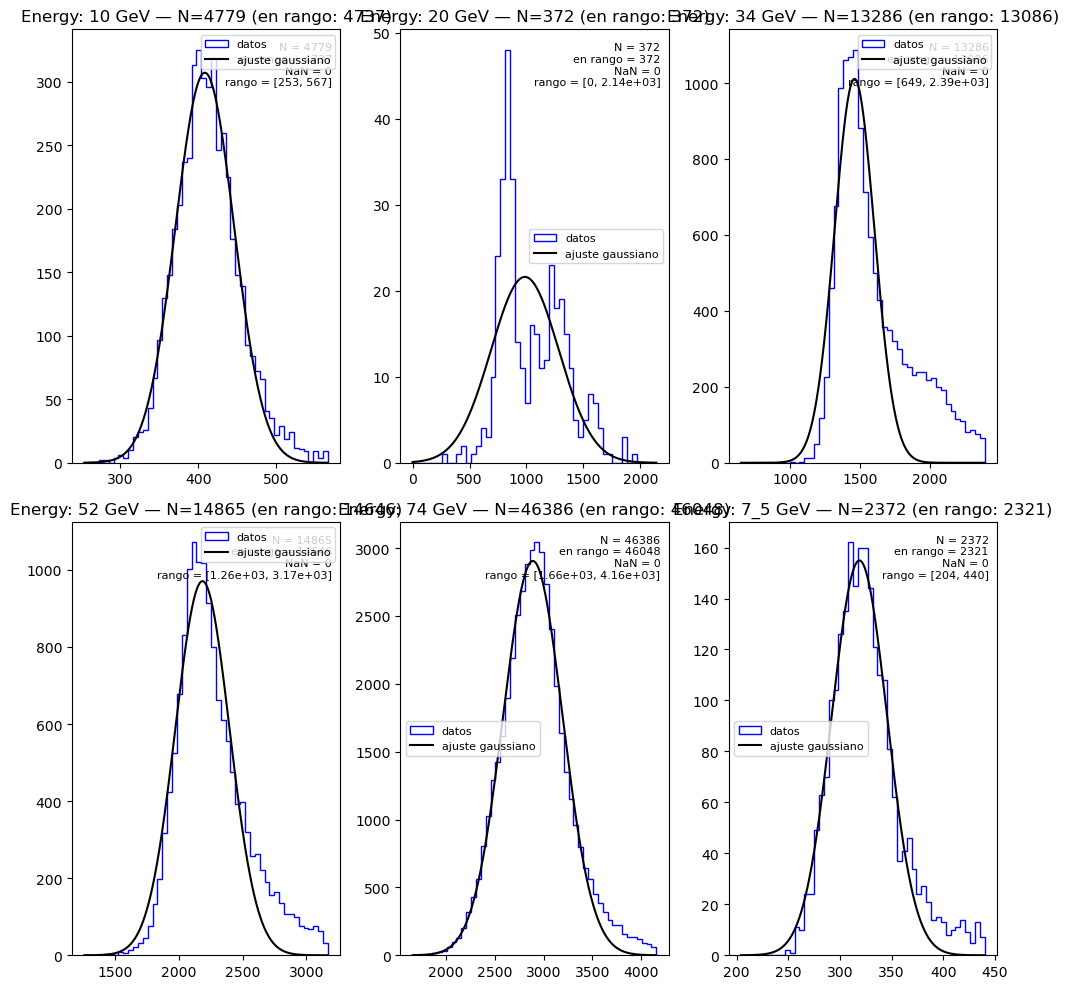

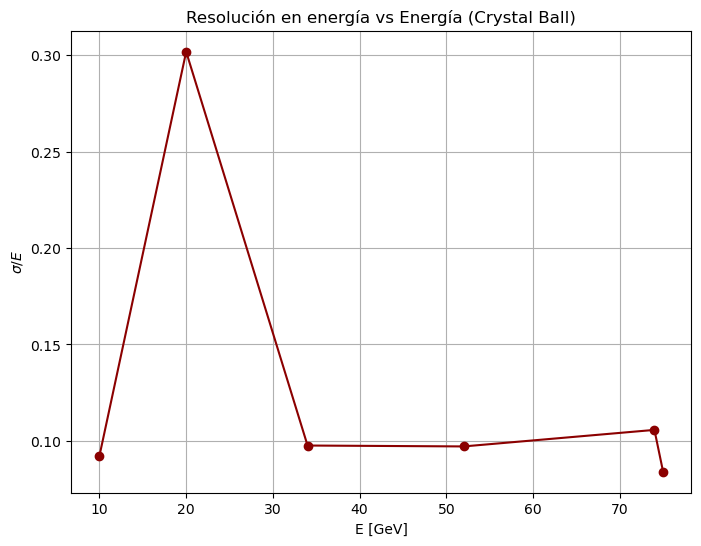

(array([10., 20., 34., 52., 74., 75.]),
 array([0.09224738, 0.30185183, 0.09758145, 0.09711338, 0.10568899,
        0.08399428]))

In [72]:
import matplotlib.pyplot as plt
results = plot_energy_fits_from_arrays(real_e, energy_fit, ranges="auto", bins=50, fit_type="gauss")
plot_resolution(results)